In [1]:
%pip install -U kaleido


  Using cached kaleido-1.2.0-py3-none-any.whl.metadata (5.6 kB)
Using cached kaleido-1.2.0-py3-none-any.whl (68 kB)
  Attempting uninstall: kaleido
    Found existing installation: kaleido 0.1.0.post1
    Uninstalling kaleido-0.1.0.post1:
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'c:\\users\\owner\\appdata\\local\\programs\\python\\python310\\lib\\site-packages\\kaleido\\executable\\bin\\icudtl.dat'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# %%
import os
import sys
from pathlib import Path

import numpy as np
try:
    import pandas as pd
except ImportError as e:
    print("Pandas import failed:", repr(e))
    print("Cascade TF2.3 env tip: keep NumPy 1.19.x and install pandas==1.1.5 (or pandas<1.2).")
    raise
import pickle
from scipy import stats
from scipy.ndimage import gaussian_filter1d
from sklearn.metrics import r2_score

# Optional plotting (avoid hard-failing if the Cascade env pins older NumPy)
try:
    import matplotlib.pyplot as plt
except Exception as e:
    plt = None
    print("Matplotlib import failed:", repr(e))
    print("Fix (conda): conda install 'numpy<1.20' 'matplotlib<3.6'")

def _guess_cascade_repo():
    env = os.environ.get("CASCADE_REPO")
    candidates = []
    if env:
        candidates.append(Path(env))
    candidates += [
        Path.cwd() / "Cascade",
        Path.cwd().parent / "Cascade",
        Path(r"C:\Users\owner\Cascade"),
    ]
    for c in candidates:
        if (c / "cascade2p").is_dir():
            return c
    return None

def import_cascade(cascade_repo=None):
    # Import Cascade (cascade2p) either installed or from a local clone path.
    try:
        import cascade2p.cascade as cascade
        return cascade
    except ModuleNotFoundError:
        pass

    repo = Path(cascade_repo) if cascade_repo else _guess_cascade_repo()
    if repo and (repo / "cascade2p").is_dir():
        sys.path.insert(0, str(repo.resolve()))
        import cascade2p.cascade as cascade
        return cascade

    raise ModuleNotFoundError(
        "Could not import 'cascade2p'. Clone HelmchenLabSoftware/Cascade and either "
        "(1) set env var CASCADE_REPO to the clone path, or (2) run 'pip install -e .' inside the clone."
    )
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
cascade = import_cascade()
print("Cascade imported from:", getattr(cascade, "__file__", "<unknown>"))

# Cascade needs TensorFlow (and compatible NumPy). If this fails, fix the env first.
try:
    import tensorflow as tf
    print("TensorFlow:", tf.__version__)
except Exception as e:
    print("TensorFlow import failed:", repr(e))
    print("Cascade pretrained models typically need TensorFlow==2.3 and Keras==2.3.1 (see Cascade README).")

CASCADE_REPO = _guess_cascade_repo()
CASCADE_MODEL_FOLDER = os.environ.get(
    "CASCADE_MODEL_FOLDER",
    str((CASCADE_REPO / "Pretrained_models").resolve()) if CASCADE_REPO else "Pretrained_models",
)
print("Cascade model folder:", CASCADE_MODEL_FOLDER)

def ensure_cascade_model(model_name, model_folder=CASCADE_MODEL_FOLDER):
    model_folder = Path(model_folder)
    model_dir = model_folder / model_name
    has_weights = model_dir.exists() and any(model_dir.rglob("*.h5"))
    if not has_weights:
        print(f"Model '{model_name}' not found in {model_dir}. Trying to download...")
        try:
            cascade.download_model(model_name, model_folder=str(model_folder))
        except Exception as e:
            raise RuntimeError(
                f"Could not find/download Cascade model '{model_name}'. "
                f"Set CASCADE_MODEL_FOLDER or download models into: {model_folder}"
            ) from e
    return str(model_folder)


c:\Users\owner\anaconda3\envs\Cascade38\lib\site-packages\_distutils_hack\__init__.py:31: UserWarning: Setuptools is replacing distutils. Support for replacing an already imported distutils is deprecated. In the future, this condition will fail. Register concerns at https://github.com/pypa/setuptools/issues/new?template=distutils-deprecation.yml
  warnings.warn(


Cascade imported from: c:\users\owner\cascade\cascade2p\cascade.py
TensorFlow: 2.3.0
Cascade model folder: C:\Users\owner\Cascade\Pretrained_models


In [3]:
def gaussian_smooth(x, sigma_samples: float):
    """Simple Gaussian smoothing (no scipy)."""
    if sigma_samples is None or sigma_samples <= 0:
        return np.asarray(x, float).copy()
    x = np.asarray(x, float)
    radius = int(np.ceil(5 * sigma_samples))
    t = np.arange(-radius, radius + 1)
    k = np.exp(-(t**2) / (2 * sigma_samples**2))
    k /= k.sum()
    return np.convolve(x, k, mode="same")

def save_plotly_svg_html(fig, svg_path, html_path):
    fig.write_image(svg_path)
    fig.write_html(html_path)

def fr_calc (spike_idx_v, n_ca, t_ca, fs_v, fr_bin_s=0.033, fr_smooth_sigma_s=0.0):
    spike_idx_v = np.asarray(spike_idx_v, dtype=int)
    if spike_idx_v.size == 0:
        fr_on_ca = np.zeros(n_ca, float)
    else:
        spike_t = spike_idx_v / float(fs_v)
        duration_s = t_ca[-1] if n_ca > 1 else 0.0

        bin_w = max(float(fr_bin_s), 1e-6)
        edges = np.arange(0, duration_s + bin_w, bin_w)
        if edges.size < 2:
            edges = np.array([0.0, bin_w])

        counts, _ = np.histogram(spike_t, bins=edges)
        fr = counts / bin_w
        t_fr = (edges[:-1] + edges[1:]) / 2.0

        # FR smoothing (optional)
        if fr_smooth_sigma_s and fr_smooth_sigma_s > 0:
            fr = gaussian_smooth(fr, sigma_samples=(fr_smooth_sigma_s / bin_w))

        # interpolate to Ca axis
        fr_on_ca = np.interp(t_ca, t_fr, fr, left=fr[0], right=fr[-1])
    return fr_on_ca

def make_padded_trace_matrix(traces_list, pad_value=np.nan, dtype=float):
    """
    traces_list: list of 1D arrays, different lengths ok
    returns: 2D array shape (n_traces, max_len)
    """
    traces_list = [np.asarray(t, dtype=dtype).ravel() for t in traces_list]
    Lmax = max(len(t) for t in traces_list)
    X = np.full((len(traces_list), Lmax), pad_value, dtype=dtype)
    for i, t in enumerate(traces_list):
        X[i, :len(t)] = t
    return X

In [4]:
DB = pd.read_csv(r'Z:\Adam-Lab-Shared\Data\Michal_Rubin\Dendrites\SST_Final.csv')
values = DB['SNR'].tolist()
r = DB
awakePyr = r['Notes']
bsPyr = list(r['brainState'])
pathPyr = list(r['Link'])
AllCalSR = list(r['CALsr'])
subG = list(r['subGroup'])
bsOnlyM = [bsPyr[i] for i, s in enumerate(subG) if s.lower() == "motion"]
onlyMot = [pathPyr[i] for i, s in enumerate(subG) if s.lower() == "motion"]
oNAllCalSR = [AllCalSR[i] for i, s in enumerate(subG) if s.lower() == "motion"]

In [5]:
import sys
print(sys.version)
print(sys.executable)


3.8.20 (default, Oct  3 2024, 15:19:54) [MSC v.1929 64 bit (AMD64)]
c:\Users\owner\anaconda3\envs\Cascade38\python.exe


In [10]:
all_cal_tr = []
all_fr_tr = []
all_vol_tr = []
all_meta = []  # one entry per trace (matches all_*_tr order)
all_path = []
all_name = []
all_spTr = []
# --- NumPy pickle compatibility shim (NumPy 2.x -> NumPy 1.x) ---
import sys as _sys
import numpy as _np
import numpy.core as _np_core
_sys.modules.setdefault('numpy._core', _np_core)
_sys.modules.setdefault('numpy._core.multiarray', _np_core.multiarray)
_sys.modules.setdefault('numpy._core._multiarray_umath', _np_core._multiarray_umath)
_sys.modules.setdefault('numpy._core.numeric', _np_core.numeric)
_sys.modules.setdefault('numpy._core.fromnumeric', _np_core.fromnumeric)
_sys.modules.setdefault('numpy._core.overrides', _np_core.overrides)
_sys.modules.setdefault('numpy._core.umath', _np_core.umath)
_sys.modules.setdefault('numpy._core.shape_base', _np_core.shape_base)

def _load_final_spikes(folder, name=None):
    candidates = []
    if name:
        candidates.append(os.path.join(folder, f"final_spikes_{name}.pkl"))
    candidates.append(os.path.join(folder, "final_spikes.pkl"))
    for p in candidates:
        if os.path.exists(p):
            with open(p, "rb") as f:
                d = pickle.load(f)
            sp = None
            if isinstance(d, dict):
                sp = d.get("spike_indices", None)
                if sp is None:
                    sp = d.get("vm_all_spikes", None)
                if sp is None:
                    sp = d.get("spikes", None)
            if sp is None:
                continue
            sp = np.asarray(sp, dtype=int).ravel().tolist()
            return sp, d, p
    return None, None, None


for i,l in enumerate(pathPyr):
    calSR= AllCalSR[i]
    TracePathCal = os.path.join(l,'calTraceDF.csv')
    TracePathVol = os.path.join(l,'volTraceDF.csv')
    TracePathCalM = os.path.join(l,'calMask.csv')
    TracePathVolM = os.path.join(l,'volMask.csv')
    parentP = os.path.dirname(l)
    MotPath = os.path.join(parentP,'Sync','MotorId.csv')
    
    
    VolTrace = pd.read_csv(TracePathVol)
    VolTrace = np.array(VolTrace)
    VolTrace = VolTrace.flatten()
    Trace = VolTrace
    motor = pd.read_csv(MotPath, header=None).iloc[:, 0]
    motor = motor[0:np.size(Trace,0)]
    CalTrace = pd.read_csv(TracePathCal)
    CalTrace = np.array(CalTrace)
    CalTrace = CalTrace.flatten()
    VolMask = pd.read_csv(TracePathVolM)
    VolMask = np.array(VolMask)
    VolMask = VolMask.flatten()
    #Trace = VolMask 
    CalMask = pd.read_csv(TracePathCalM)
    CalMask = np.array(CalMask)
    CalMask = CalMask.flatten()
    TraceV = Trace.copy().astype(float)
    TraceC = CalTrace.copy().astype(float)
    motor = motor.to_numpy().astype(float)
    TraceV[~VolMask] = np.nan
    TraceC[~CalMask] = np.nan
    motor[~VolMask] = np.nan
    VolAX = np.linspace(0, (len(TraceV)/500), len(TraceV)) 
    CalAX = np.linspace(0, (len(TraceC)/calSR), len(TraceC))
    all_cal_tr.append(TraceC)
    all_vol_tr.append(TraceV)
    fpath = os.path.join(l,r'SpikeIdxFinal.csv')
    spike_indices, _spk_payload, _spk_path = _load_final_spikes(l)
    all_meta.append({'cell_path': l, 'state': bsPyr[i]})
    frCAL = fr_calc(spike_indices, len(TraceC), CalAX, 500, fr_bin_s=0.033, fr_smooth_sigma_s=0.0)
    all_fr_tr.append(frCAL)
    all_path.append(l)
    all_spTr.append(spike_indices)

In [11]:



def _to_2d(arr, name="array"):
    """Force arr into shape (n_cells, n_time). Accepts (n_time,), (n_cells, n_time), or list of 1D arrays."""
    if arr is None:
        return None
    arr = np.asarray(arr, dtype=object) if isinstance(arr, (list, tuple)) else np.asarray(arr)
    if arr.ndim == 1:
        # could be (n_time,) single cell
        return np.asarray(arr, dtype=float)[None, :]
    if arr.ndim == 2:
        return np.asarray(arr, dtype=float)
    raise ValueError(f"{name} must be 1D or 2D; got shape {arr.shape}")


def voltage_spikes_to_fr_on_ca(spike_idx_v, n_v, fs_v, fs_ca, n_ca, smooth_sigma_s=0.0):
    """Bin voltage spikes into calcium frames -> FR at calcium rate (Hz)."""
    spike_idx_v = np.asarray(spike_idx_v, dtype=int)
    spike_idx_v = spike_idx_v[(spike_idx_v >= 0) & (spike_idx_v < n_v)]

    s_v = np.zeros(n_v, dtype=float)
    s_v[spike_idx_v] = 1.0

    # edges in voltage samples for each calcium frame
    edges = (np.arange(n_ca + 1) / fs_ca * fs_v).astype(int)
    edges = np.clip(edges, 0, n_v)

    counts = np.add.reduceat(s_v, edges[:-1])  # spikes per ca-frame
    fr = counts * fs_ca  # Hz (spikes per frame * frames per sec)

    if smooth_sigma_s and smooth_sigma_s > 0:
        from scipy.ndimage import gaussian_filter1d
        fr = gaussian_filter1d(fr, sigma=smooth_sigma_s * fs_ca, mode="nearest")

    return fr


def make_cell_plotly_figure(
    *,
    cell_name: str,
    cal: np.ndarray, fs_ca: float,
    vol: np.ndarray, fs_v: float,
    spike_idx_v: np.ndarray,
    cascade_out: np.ndarray,  # same length as cal (or will be trimmed)
    fr_on_ca: np.ndarray = None,  # optional; if None, computed from spike_idx_v
    fr_smooth_sigma_s: float = 0.0,
    show_spike_markers: bool = True,
):
    """
    Returns a plotly Figure with 3 rows:
      1) CASCADE output vs time (calcium time axis)
      2) Calcium (left y) + Voltage (right y) + spikes on voltage
      3) Actual FR (at calcium sampling)
    """

    cal = np.asarray(cal, dtype=float).ravel()
    vol = np.asarray(vol, dtype=float).ravel()
    cascade_out = np.asarray(cascade_out, dtype=float).ravel()

    # time axes
    t_ca = np.arange(len(cal)) / fs_ca
    t_v = np.arange(len(vol)) / fs_v

    # align cascade_out to calcium
    n_ca = min(len(cal), len(cascade_out))
    cal = cal[:n_ca]
    t_ca = t_ca[:n_ca]
    cascade_out = cascade_out[:n_ca]

    # FR at calcium rate
    if fr_on_ca is None:
        fr_on_ca = voltage_spikes_to_fr_on_ca(
            spike_idx_v=spike_idx_v,
            n_v=len(vol),
            fs_v=fs_v,
            fs_ca=fs_ca,
            n_ca=n_ca,
            smooth_sigma_s=fr_smooth_sigma_s,
        )
    else:
        fr_on_ca = np.asarray(fr_on_ca, dtype=float).ravel()[:n_ca]

    # spike markers on voltage trace
    spike_idx_v = np.asarray(spike_idx_v, dtype=int)
    spike_idx_v = spike_idx_v[(spike_idx_v >= 0) & (spike_idx_v < len(vol))]
    t_spk = spike_idx_v / fs_v
    v_spk = vol[spike_idx_v] if len(spike_idx_v) else np.array([])

    fig = make_subplots(
        rows=2, cols=1,
        shared_xaxes=False,
        vertical_spacing=0.08,
        specs=[
            [{"secondary_y": True}],  # row 1
            [{"secondary_y": True}],   # row 2 calcium+voltage
            
        ],
        subplot_titles=(
            "CASCADE output (calcium sampling) + FR",
            "Calcium + Voltage (spikes marked on voltage)",
           
        )
    )

    # --- Row 1: CASCADE ---
    fig.add_trace(
        go.Scatter(
            x=t_ca, y=cascade_out,
            mode="lines",
            name="CASCADE",
            line=dict(width=1,color="aqua"),
        ),
        row=1, col=1
    )

    # --- Row 2: Calcium + Voltage ---
    fig.add_trace(
        go.Scatter(
            x=t_ca, y=cal,
            mode="lines",
            name="Calcium",
            line=dict(width=1,color="blue"),
        ),
        row=2, col=1, secondary_y=False
    )

    fig.add_trace(
        go.Scatter(
            x=t_v, y=vol,
            mode="lines",
            name="Voltage",
            line=dict(width=1, color="red"),
        ),
        row=2, col=1, secondary_y=True
    )

    if show_spike_markers and len(t_spk):
        fig.add_trace(
            go.Scatter(
                x=t_spk, y=v_spk,
                mode="markers",
                name="Spikes",
                marker=dict(size=6, color="black"),
            ),
            row=2, col=1, secondary_y=True
        )

    
    fig.add_trace(
        go.Scatter(
            x=t_ca, y=fr_on_ca,
            mode="lines",
            name="FR on Ca",
            line=dict(width=1,color="maroon"),
        ),
        row=1, col=1, secondary_y=True
        
    )

    # axis labels
    fig.update_xaxes(title_text="Time (s)", row=1, col=1)
    fig.update_xaxes(title_text="Time (s)", row=2, col=1)


    fig.update_yaxes(title_text="CASCADE output", row=1, col=1, secondary_y=False)
    fig.update_yaxes(title_text="Calcium (a.u.)", row=2, col=1, secondary_y=False)
    fig.update_yaxes(title_text="Voltage (a.u.)", row=2, col=1, secondary_y=True)
    fig.update_yaxes(title_text="FR (Hz)", row=1, col=1, secondary_y=True)

    fig.update_layout(
        title=f"{cell_name}",
        height=900,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
        margin=dict(l=60, r=60, t=80, b=60),
    )

    return fig



In [9]:
%pip install -U kaleido

Note: you may need to restart the kernel to use updated packages.


In [12]:
traces_2d_cal = make_padded_trace_matrix(all_cal_tr, pad_value=np.nan)
traces_2d_FR = make_padded_trace_matrix(all_fr_tr, pad_value=np.nan)

model_name = "Interneurons_GC8+_30Hz_smoothing50ms_high_noise"
model_folder = ensure_cascade_model(model_name, CASCADE_MODEL_FOLDER)
predict_fr_cascade = cascade.predict(model_name=model_name, traces=traces_2d_cal, model_folder=model_folder)
for i,k in enumerate(all_name):
    cal_i = all_cal_tr[i]
    cas_i = predict_fr_cascade[i]
    vol_i = all_vol_tr[i] 
    spk_i = all_spTr[i]  # 1D indices into vol_i
    out_dir = all_path[i]
    calSR_i = float(AllCalSR[i]) if ('AllCalSR' in globals() and i < len(AllCalSR) and np.isfinite(AllCalSR[i]) and float(AllCalSR[i]) > 0) else 30.0
    fig = make_cell_plotly_figure(
        cell_name=k,
        cal=cal_i, fs_ca=calSR_i,
        vol=vol_i, fs_v=500.0,
        spike_idx_v=spk_i,
        cascade_out=cas_i,
        fr_on_ca=all_fr_tr[i],
        fr_smooth_sigma_s=0.025,
        show_spike_markers=True,
    )
    out_svg = os.path.join(out_dir, f'cascade_analysis_{k}.svg')
    out_html = os.path.join(out_dir, f'cascade_analysis_{k}.html')
    save_plotly_svg_html(fig, out_svg, out_html)    


Model 'Interneurons_GC8+_30Hz_smoothing50ms_high_noise' not found in C:\Users\owner\Cascade\Pretrained_models\Interneurons_GC8+_30Hz_smoothing50ms_high_noise. Trying to download...
Pretrained model was saved in folder "C:\Users\owner\Cascade\Pretrained_models\Interneurons_GC8+_30Hz_smoothing50ms_high_noise"

 
The selected model was trained on 1 datasets, with 5 ensembles for each noise level, at a sampling rate of 30.0Hz, with a resampled ground truth that was smoothed with a Gaussian kernel of a standard deviation of 50 milliseconds. 
 

Loaded model was trained at frame rate 30.0 Hz
Given argument traces contains 82 neurons and 3784 frames.
Noise levels (mean, std; in standard units): 3.45, 2.72

Predictions for noise level 2:
	... ensemble 0
134/134 [==============================] - 1s 5ms/step
	... ensemble 1
134/134 [==============================] - 1s 5ms/step
	... ensemble 2
134/134 [==============================] - 1s 5ms/step
	... ensemble 3
134/134 [======================

In [2]:
%pip uninstall -y plotly kaleido
%pip install "plotly>=5.18" "kaleido==0.2.1"


Found existing installation: plotly 5.24.1
Uninstalling plotly-5.24.1:
  Successfully uninstalled plotly-5.24.1
Found existing installation: kaleido 1.2.0
Uninstalling kaleido-1.2.0:
  Successfully uninstalled kaleido-1.2.0
Note: you may need to restart the kernel to use updated packages.
  Using cached plotly-6.5.2-py3-none-any.whl.metadata (8.5 kB)
  Using cached kaleido-0.2.1-py2.py3-none-win_amd64.whl.metadata (15 kB)
Using cached kaleido-0.2.1-py2.py3-none-win_amd64.whl (65.9 MB)
Using cached plotly-6.5.2-py3-none-any.whl (9.9 MB)
Note: you may need to restart the kernel to use updated packages.


In [13]:
import plotly
import plotly.io as pio
import kaleido
import sys

print("python:", sys.executable)
print("plotly:", plotly.__version__)
print("kaleido:", kaleido.__version__)
print("kaleido scope is None?", pio.kaleido.scope is None)


python: c:\Users\owner\anaconda3\envs\Cascade38\python.exe
plotly: 6.5.2
kaleido: 0.2.1
kaleido scope is None? False


In [18]:
# Compare voltage-derived FR vs Cascade prediction; save CSV indices + SVG/HTML figures
from pathlib import Path
import numpy as np

FALLBACK_OUT_DIR = Path(r'Z:\Adam-Lab-Shared\Data\Michal_Rubin\data summery\2026\SST\cascade') / 'fr_predict_diff_outputs'
FALLBACK_OUT_DIR.mkdir(parents=True, exist_ok=True)

FS_VOL_HZ = 500.0
FS_CA_DEFAULT_HZ = 30.0

# --- Plot + difference detection settings ---
PLOT_Y_MODE = 'zscore'          # 'hz' (recommended) or 'zscore'
DIFF_METHOD = 'resid_robust_z'  # 'resid_robust_z' (recommended) or 'zscore_diff'
RESID_Z_K = 3.0             # threshold for residual robust-z
ZSCORE_DIFF_K = 3.0         # threshold for |z(real)-z(pred)| if DIFF_METHOD='zscore_diff'
MIN_SEG_DUR_S = 0.30        # merge diffs into segments; keep segments >= this duration
MAX_VLINES = 200            # plot at most this many purple dashed lines per cell
YLIM_PAD_FRAC = 0.05        # padding for FR y-limits

def _robust_z(x: np.ndarray):
    x = np.asarray(x, float)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    scale = 1.4826 * mad
    if not np.isfinite(scale) or scale <= 0:
        scale = np.nanstd(x)
    if not np.isfinite(scale) or scale <= 0:
        scale = 1.0
    return (x - med) / scale, med, scale

def _contiguous_regions(mask: np.ndarray) -> np.ndarray:
    mask = np.asarray(mask, dtype=bool)
    if mask.size == 0:
        return np.zeros((0, 2), dtype=int)
    d = np.diff(mask.astype(int), prepend=0, append=0)
    starts = np.where(d == 1)[0]
    ends = np.where(d == -1)[0] - 1
    if starts.size == 0:
        return np.zeros((0, 2), dtype=int)
    return np.stack([starts, ends], axis=1)

pred = np.asarray(predict_fr_cascade)
n = min(len(all_fr_tr), len(all_vol_tr), len(all_meta), int(pred.shape[0]))
if n == 0:
    raise RuntimeError('No traces to compare. Check that all_fr_tr/all_vol_tr/all_meta and predict_fr_cascade exist.')

summary_rows = []
for idx in range(n):
    fr_real = np.asarray(all_fr_tr[idx], dtype=float).ravel()
    vol = np.asarray(all_vol_tr[idx], dtype=float).ravel()
    meta = all_meta[idx] if isinstance(all_meta[idx], dict) else {'cell_path': str(all_meta[idx]), 'state': '', 'segment': ''}

    fs_ca_hz = float(FS_CA_DEFAULT_HZ)
    if 'AllCalSR' in globals() and AllCalSR is not None and idx < len(AllCalSR):
        try:
            fs_candidate = float(AllCalSR[idx])
            if np.isfinite(fs_candidate) and fs_candidate > 0:
                fs_ca_hz = fs_candidate
        except Exception:
            pass

    cell_path = meta.get('cell_path', '')
    if (not cell_path) and ('all_path' in globals()) and (idx < len(all_path)):
        cell_path = all_path[idx]
    try:
        cell_path_str = str(cell_path).strip()
        if not cell_path_str:
            raise ValueError('empty cell path')
        cell_out_dir = Path(cell_path_str)
        cell_out_dir.mkdir(parents=True, exist_ok=True)
    except Exception:
        cell_out_dir = FALLBACK_OUT_DIR
        cell_out_dir.mkdir(parents=True, exist_ok=True)

    fr_pred_raw = np.asarray(pred[idx], dtype=float).ravel()[: fr_real.size]

    t_ca = np.arange(fr_real.size, dtype=float) / fs_ca_hz
    finite = np.isfinite(fr_real) & np.isfinite(fr_pred_raw)

    # Scale/shift prediction to match FR units (Hz)
    if np.sum(finite) >= 2:
        a, b = np.polyfit(fr_pred_raw[finite], fr_real[finite], 1)
    else:
        a, b = 1.0, 0.0
    fr_pred_scaled = a * fr_pred_raw + b

    # Z-scored versions (shape-only comparison)
    z_real, z_real_med, z_real_scale = _robust_z(fr_real)
    z_pred, z_pred_med, z_pred_scale = _robust_z(fr_pred_scaled)

    # Difference mask
    if DIFF_METHOD == 'zscore_diff':
        diff_mask = finite & (np.abs(z_real - z_pred) > float(ZSCORE_DIFF_K))
        resid = (z_real - z_pred)
        rz = resid  # already in z units
        resid_med, resid_scale = 0.0, 1.0
    else:
        resid = np.full(fr_real.shape, np.nan, dtype=float)
        resid[finite] = fr_real[finite] - fr_pred_scaled[finite]
        rz, resid_med, resid_scale = _robust_z(resid)
        diff_mask = finite & (np.abs(rz) > float(RESID_Z_K))

    diff_idx = np.where(diff_mask)[0]

    # Merge to segments and filter by min duration
    regions = _contiguous_regions(diff_mask)
    min_len = int(np.ceil(MIN_SEG_DUR_S * fs_ca_hz))
    min_len = max(min_len, 1)
    if regions.size:
        keep = (regions[:, 1] - regions[:, 0] + 1) >= min_len
        regions = regions[keep]

    # CSV: point indices
    abs_diff = np.full(fr_real.shape, np.nan, dtype=float)
    abs_diff[finite] = np.abs(fr_real[finite] - fr_pred_scaled[finite])

    df_pts = pd.DataFrame({
        'cell_idx': idx,
        'cell_path': meta.get('cell_path', ''),
        'state': meta.get('state', ''),
        'segment': meta.get('segment', ''),
        'frame_idx_0based': diff_idx.astype(int),
        't_s': t_ca[diff_idx],
        'fr_real_hz': fr_real[diff_idx],
        'fr_pred_scaled_hz': fr_pred_scaled[diff_idx],
        'fr_pred_raw': fr_pred_raw[diff_idx],
        'resid': resid[diff_idx],
        'resid_metric': rz[diff_idx],
        'abs_diff_hz': abs_diff[diff_idx],
        'fit_a': float(a),
        'fit_b': float(b),
        'diff_method': DIFF_METHOD,
        'fs_ca_hz': float(fs_ca_hz),
        'RESID_Z_K': float(RESID_Z_K),
        'ZSCORE_DIFF_K': float(ZSCORE_DIFF_K),
        'fr_real_z': z_real[diff_idx],
        'fr_pred_z': z_pred[diff_idx],
        'resid_med': float(resid_med),
        'resid_scale': float(resid_scale),
    })
    csv_pts = cell_out_dir / f'fr_predict_diff{idx}.csv'
    df_pts.to_csv(csv_pts, index=False)

    # CSV: segments
    seg_rows = []
    for s, e in regions:
        seg_resid = resid[s:e+1]
        seg_abs = np.abs(seg_resid[np.isfinite(seg_resid)])
        seg_rows.append({
            'cell_idx': idx,
            'cell_path': meta.get('cell_path', ''),
            'state': meta.get('state', ''),
            'segment': meta.get('segment', ''),
            'start_idx_0based': int(s),
            'end_idx_0based': int(e),
            'start_t_s': float(t_ca[s]),
            'end_t_s': float(t_ca[e]),
            'duration_s': float((e - s + 1) / fs_ca_hz),
            'fs_ca_hz': float(fs_ca_hz),
            'mean_abs_resid': float(np.nanmean(seg_abs)) if seg_abs.size else np.nan,
            'peak_abs_resid': float(np.nanmax(seg_abs)) if seg_abs.size else np.nan,
            'mean_resid': float(np.nanmean(seg_resid)),
            'direction': 'underpredict' if np.nanmean(seg_resid) > 0 else 'overpredict',
        })
    df_seg = pd.DataFrame(seg_rows)
    csv_seg = cell_out_dir / f'fr_predict_diff_segments{idx}.csv'
    df_seg.to_csv(csv_seg, index=False)

    finite_abs = abs_diff[np.isfinite(abs_diff)]
    summary_rows.append({
        'cell_idx': idx,
        'cell_path': meta.get('cell_path', ''),
        'state': meta.get('state', ''),
        'segment': meta.get('segment', ''),
        'diff_method': DIFF_METHOD,
        'out_dir': str(cell_out_dir),
        'fs_ca_hz': float(fs_ca_hz),
        'n_frames': int(fr_real.size),
        'n_diff_frames': int(diff_idx.size),
        'n_diff_segments': int(len(regions)),
        'diff_frac': float(diff_idx.size) / float(fr_real.size) if fr_real.size else np.nan,
        'median_abs_diff_hz': float(np.nanmedian(abs_diff)),
        'p95_abs_diff_hz': float(np.nanpercentile(finite_abs, 95)) if finite_abs.size else np.nan,
        'fit_a': float(a),
        'fit_b': float(b),
        'resid_med': float(resid_med),
        'resid_scale': float(resid_scale),
    })

    if plt is None:
        continue

    # Choose what to plot on FR axis
    if PLOT_Y_MODE == 'zscore':
        y_real = z_real
        y_pred = z_pred
        y_label = 'Z-scored FR (a.u.)'
    else:
        y_real = fr_real
        y_pred = fr_pred_scaled
        y_label = 'Firing rate (Hz)'

    centers = ((regions[:, 0] + regions[:, 1]) // 2).astype(int) if regions.size else np.array([], dtype=int)
    if centers.size > MAX_VLINES:
        pick = np.linspace(0, centers.size - 1, MAX_VLINES).astype(int)
        centers = centers[pick]

    fig, ax1 = plt.subplots(figsize=(12, 4))
    ax1.plot(t_ca, y_real, color='black', linewidth=1.0, label='Real FR')
    ax1.plot(t_ca, y_pred, color='red', linewidth=1.0, label='Cascade FR')
    for c in centers:
        if 0 <= c < t_ca.size:
            ax1.axvline(t_ca[c], color='purple', linestyle='--', linewidth=0.9, alpha=0.8)
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel(y_label)

    # Force the y-axis to cover BOTH traces (same scale)
    y_all = np.concatenate([y_real[np.isfinite(y_real)], y_pred[np.isfinite(y_pred)]])
    if y_all.size:
        ymin = float(np.nanmin(y_all))
        ymax = float(np.nanmax(y_all))
        if np.isfinite(ymin) and np.isfinite(ymax):
            if ymin == ymax:
                ymin -= 1.0
                ymax += 1.0
            pad = (ymax - ymin) * float(YLIM_PAD_FRAC)
            ax1.set_ylim(ymin - pad, ymax + pad)

    ax2 = ax1.twinx()
    t_vol = np.arange(vol.size, dtype=float) / FS_VOL_HZ
    ax2.plot(t_vol, vol, color='0.6', linewidth=0.5, alpha=0.6, label='Voltage')
    ax2.set_ylabel('Voltage (a.u.)')

    if t_ca.size and t_vol.size:
        ax1.set_xlim(0, float(min(t_ca[-1], t_vol[-1])))
    elif t_ca.size:
        ax1.set_xlim(0, float(t_ca[-1]))
    elif t_vol.size:
        ax1.set_xlim(0, float(t_vol[-1]))

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc='upper right', fontsize=8)

    ax1.set_title(f"cell={idx} state={meta.get('state','')} seg={meta.get('segment','')} method={DIFF_METHOD} nSeg={len(regions)} nPts={diff_idx.size}")
    fig.tight_layout()

    png_path = cell_out_dir / f'fr_predict_diff{idx}.png'
    svg_path = cell_out_dir / f'fr_predict_diff{idx}.svg'
    html_path = cell_out_dir / f'fr_predict_diff{idx}.html'

    fig.savefig(png_path, dpi=200)
    fig.savefig(svg_path)
    plt.close(fig)

    html = f"""<!doctype html>
<html>
<head>
  <meta charset='utf-8'>
  <title>fr_predict_diff{idx}</title>
</head>
<body>
  <h3>fr_predict_diff{idx}</h3>
  <p>cell_path: {meta.get('cell_path','')}</p>
  <p>state: {meta.get('state','')} segment: {meta.get('segment','')}</p>
  <p>PLOT_Y_MODE={PLOT_Y_MODE} DIFF_METHOD={DIFF_METHOD}</p>
  <p>RESID_Z_K={RESID_Z_K} ZSCORE_DIFF_K={ZSCORE_DIFF_K} MIN_SEG_DUR_S={MIN_SEG_DUR_S}</p>
  <p>CSV points: {csv_pts.name}</p>
  <p>CSV segments: {csv_seg.name}</p>
  <object type='image/svg+xml' data='{svg_path.name}' width='100%'></object>
</body>
</html>
"""
    html_path.write_text(html, encoding='utf-8')

summary_df = pd.DataFrame(summary_rows)
if not summary_df.empty:
    for _out_dir, _grp in summary_df.groupby('out_dir', sort=True):
        _out_path = Path(str(_out_dir))
        _out_path.mkdir(parents=True, exist_ok=True)
        _grp.to_csv(_out_path / 'fr_predict_diff_summary.csv', index=False)
    print('Saved diff CSVs/figures to local DB folders. Example:', summary_df['out_dir'].iloc[0])
else:
    print('No traces to save.')


Saved diff CSVs/figures to local DB folders. Example: Z:\Adam-Lab-Shared\Data\Michal_Rubin\srugc17\Xb\17-06-2025\fov1\cell1


In [15]:
import numpy as np
from sklearn.metrics import r2_score

y_true = np.asarray(traces_2d_FR).astype(float).ravel()
y_pred = np.asarray(predict_fr_cascade).astype(float).ravel()

# 1) sanity: lengths must match
n = min(len(y_true), len(y_pred))
y_true = y_true[:n]
y_pred = y_pred[:n]

# 2) remove NaN/inf
valid = np.isfinite(y_true) & np.isfinite(y_pred)

print("Total points:", n, "Valid points:", valid.sum(), "Dropped:", (~valid).sum())

# If almost nothing is valid, stop early
if valid.sum() < 2:
    raise ValueError("Not enough valid points after removing NaN/inf.")

r2 = r2_score(y_true[valid], y_pred[valid])
print(f"Cascade FR prediction R^2 (finite only): {r2:.4f}")


Total points: 310288 Valid points: 233556 Dropped: 76732
Cascade FR prediction R^2 (finite only): -0.5641


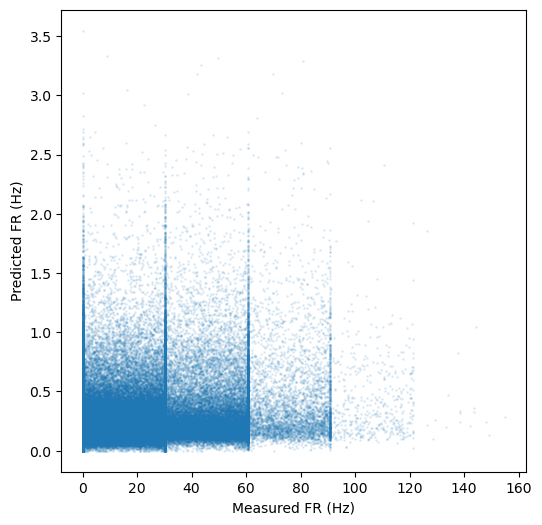

Cascade FR prediction R^2: -0.5641


ValueError: x and y must be the same size

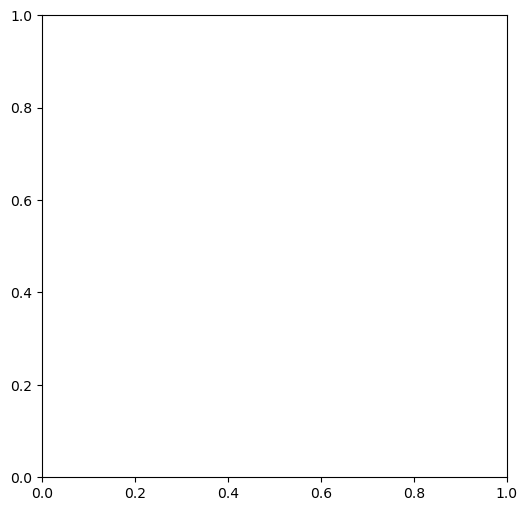

In [17]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(traces_2d_FR.flatten(), predict_fr_cascade.flatten(), s=1, alpha=0.1)
ax.set_xlabel('Measured FR (Hz)')
ax.set_ylabel('Predicted FR (Hz)')
plt.show()

# f --- IGNORE ---inally:
#     # --- Remove NumPy pickle compatibility shim ---    
#     for mod_name in [
#         'numpy._core',
#         'numpy._core.multiarray',
#         'numpy._core._multiarray_umath',
#         'numpy._core.numeric',
#         'numpy._core.fromnumeric',
#         'numpy._core.overrides',
#         'numpy._core.umath',
#         'numpy._core.shape_base',]:
#         _sys.modules.pop(mod_name, None)

print(f'Cascade FR prediction R^2: {r2:.4f}')

fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(t_ca.flatten(), predict_fr_cascade[1], s=1, alpha=0.1)
save_plotly_svg_html(fig, r'Z:\Adam-Lab-Shared\Data\Michal_Rubin\data summery\2026\SST\fr_predict_scatter_time.svg', r'Z:\Adam-Lab-Shared\Data\Michal_Rubin\data summery\2026\SST\fr_predict_scatter_time.html')

In [ ]:
# Comprehensive comparison: real FR vs Cascade-predicted FR (per-cell lag + scaling + plots)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PLOT_DIR = Path(r'Z:\\Adam-Lab-Shared\\Data\\Michal_Rubin\\data summery\\2026\\SST\\cascade') / 'fr_compare_summary'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

MAX_LAG_S = 0.50
EVENT_Z_K = 2.0
RESID_OUTLIER_K = 3.0
MIN_VALID_POINTS = 30
FS_CA_FALLBACK_HZ = 30.0
RNG = np.random.default_rng(0)

import re


def _safe_model_tag(name):
    s = str(name) if name is not None else 'unknown_model'
    s = re.sub(r'[^A-Za-z0-9._-]+', '_', s).strip('_')
    return s if s else 'unknown_model'


MODEL_NAME_USED = globals().get('model_name', 'unknown_model')
MODEL_TAG = _safe_model_tag(MODEL_NAME_USED)
print(f'Using model tag for saved outputs: {MODEL_TAG}')

def _robust_z(x):
    x = np.asarray(x, dtype=float)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    scale = 1.4826 * mad
    if (not np.isfinite(scale)) or (scale <= 0):
        scale = np.nanstd(x)
    if (not np.isfinite(scale)) or (scale <= 0):
        scale = 1.0
    return (x - med) / scale

def _shift_with_nan(x, lag_frames):
    x = np.asarray(x, dtype=float)
    y = np.full_like(x, np.nan, dtype=float)
    n = x.size
    if n == 0:
        return y
    lag = int(lag_frames)
    if lag == 0:
        return x.copy()
    if abs(lag) >= n:
        return y
    if lag > 0:
        y[:-lag] = x[lag:]
    else:
        y[-lag:] = x[:lag]
    return y

def _pearson(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if x.size < 2 or y.size < 2:
        return np.nan
    sx = np.nanstd(x)
    sy = np.nanstd(y)
    if (not np.isfinite(sx)) or (not np.isfinite(sy)) or sx <= 0 or sy <= 0:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])

def _spearman(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if x.size < 2 or y.size < 2:
        return np.nan
    rx = pd.Series(x).rank(method='average').to_numpy(dtype=float)
    ry = pd.Series(y).rank(method='average').to_numpy(dtype=float)
    return _pearson(rx, ry)

def _event_prf1(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=bool)
    y_pred = np.asarray(y_pred, dtype=bool)
    tp = np.sum(y_true & y_pred)
    fp = np.sum((~y_true) & y_pred)
    fn = np.sum(y_true & (~y_pred))
    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    f1 = (2 * precision * recall / (precision + recall)) if np.isfinite(precision) and np.isfinite(recall) and (precision + recall) > 0 else np.nan
    return precision, recall, f1

def _best_lag_frames(fr_real, fr_pred, max_lag_frames):
    zr = _robust_z(fr_real)
    zp = _robust_z(fr_pred)
    best_lag = 0
    best_corr = -np.inf
    for lag in range(-max_lag_frames, max_lag_frames + 1):
        zps = _shift_with_nan(zp, lag)
        m = np.isfinite(zr) & np.isfinite(zps)
        if np.sum(m) < MIN_VALID_POINTS:
            continue
        c = _pearson(zr[m], zps[m])
        if np.isfinite(c) and c > best_corr:
            best_corr = c
            best_lag = lag
    if best_corr == -np.inf:
        return 0, np.nan
    return int(best_lag), float(best_corr)

pred2d = np.asarray(predict_fr_cascade, dtype=float)
n_cells = min(len(all_fr_tr), int(pred2d.shape[0]), len(all_meta))
rows = []
pooled_real = []
pooled_pred = []

for idx in range(n_cells):
    fr_real = np.asarray(all_fr_tr[idx], dtype=float).ravel()
    fr_pred = np.asarray(pred2d[idx], dtype=float).ravel()[:fr_real.size]
    meta = all_meta[idx] if isinstance(all_meta[idx], dict) else {'cell_path': str(all_meta[idx]), 'state': '', 'segment': ''}

    fs_ca_hz = float(FS_CA_FALLBACK_HZ)
    if 'AllCalSR' in globals() and AllCalSR is not None and idx < len(AllCalSR):
        try:
            fs_candidate = float(AllCalSR[idx])
            if np.isfinite(fs_candidate) and fs_candidate > 0:
                fs_ca_hz = fs_candidate
        except Exception:
            pass

    max_lag_frames = max(int(round(MAX_LAG_S * fs_ca_hz)), 0)
    lag_frames, lag_corr = _best_lag_frames(fr_real, fr_pred, max_lag_frames)
    fr_pred_aligned = _shift_with_nan(fr_pred, lag_frames)

    valid_raw = np.isfinite(fr_real) & np.isfinite(fr_pred_aligned)
    n_valid = int(np.sum(valid_raw))

    if n_valid >= MIN_VALID_POINTS and np.nanstd(fr_pred_aligned[valid_raw]) > 1e-12:
        a, b = np.polyfit(fr_pred_aligned[valid_raw], fr_real[valid_raw], 1)
    else:
        a, b = 1.0, 0.0

    fr_pred_scaled = a * fr_pred_aligned + b
    valid = np.isfinite(fr_real) & np.isfinite(fr_pred_scaled)

    pearson_raw = _pearson(fr_real[valid], fr_pred_aligned[valid]) if np.sum(valid) >= MIN_VALID_POINTS else np.nan
    spearman_raw = _spearman(fr_real[valid], fr_pred_aligned[valid]) if np.sum(valid) >= MIN_VALID_POINTS else np.nan
    pearson_scaled = _pearson(fr_real[valid], fr_pred_scaled[valid]) if np.sum(valid) >= MIN_VALID_POINTS else np.nan
    spearman_scaled = _spearman(fr_real[valid], fr_pred_scaled[valid]) if np.sum(valid) >= MIN_VALID_POINTS else np.nan

    if np.sum(valid) >= MIN_VALID_POINTS:
        resid = fr_real[valid] - fr_pred_scaled[valid]
        mae = float(np.nanmean(np.abs(resid)))
        rmse = float(np.sqrt(np.nanmean(resid ** 2)))
        ss_res = float(np.nansum(resid ** 2))
        ss_tot = float(np.nansum((fr_real[valid] - np.nanmean(fr_real[valid])) ** 2))
        r2_scaled = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan
        rz = _robust_z(resid)
        outlier_frac = float(np.nanmean(np.abs(rz) > RESID_OUTLIER_K))

        z_real = _robust_z(fr_real[valid])
        z_pred = _robust_z(fr_pred_scaled[valid])
        ev_real = z_real > EVENT_Z_K
        ev_pred = z_pred > EVENT_Z_K
        ev_precision, ev_recall, ev_f1 = _event_prf1(ev_real, ev_pred)

        take_n = min(3000, int(np.sum(valid)))
        if take_n > 0:
            vidx = np.where(valid)[0]
            if take_n < vidx.size:
                sel = RNG.choice(vidx, size=take_n, replace=False)
            else:
                sel = vidx
            pooled_real.append(fr_real[sel])
            pooled_pred.append(fr_pred_scaled[sel])
    else:
        mae = np.nan
        rmse = np.nan
        r2_scaled = np.nan
        outlier_frac = np.nan
        ev_precision = np.nan
        ev_recall = np.nan
        ev_f1 = np.nan

    rows.append({
        'cell_idx': int(idx),
        'cell_path': meta.get('cell_path', ''),
        'state': meta.get('state', ''),
        'segment': meta.get('segment', ''),
        'fs_ca_hz': float(fs_ca_hz),
        'n_frames': int(fr_real.size),
        'n_valid': int(np.sum(valid)),
        'lag_frames': int(lag_frames),
        'lag_s': float(lag_frames / fs_ca_hz) if fs_ca_hz > 0 else np.nan,
        'lag_corr_z': float(lag_corr) if np.isfinite(lag_corr) else np.nan,
        'fit_a': float(a),
        'fit_b': float(b),
        'pearson_raw': pearson_raw,
        'spearman_raw': spearman_raw,
        'pearson_scaled': pearson_scaled,
        'spearman_scaled': spearman_scaled,
        'r2_scaled': r2_scaled,
        'mae_hz': mae,
        'rmse_hz': rmse,
        'resid_outlier_frac': outlier_frac,
        'event_precision': ev_precision,
        'event_recall': ev_recall,
        'f1_event': ev_f1,
    })

summary_df = pd.DataFrame(rows).sort_values('cell_idx').reset_index(drop=True)
summary_csv = PLOT_DIR / 'fr_vs_cascade_per_cell_summary.csv'
summary_df.to_csv(summary_csv, index=False)
print('Saved summary CSV:', summary_csv)
print(summary_df.head(10).to_string(index=False))

metrics_for_report = ['pearson_scaled', 'spearman_scaled', 'r2_scaled', 'mae_hz', 'rmse_hz', 'f1_event', 'lag_s']
print('\
Aggregate (median across cells):')
for k in metrics_for_report:
    vals = summary_df[k].to_numpy(dtype=float)
    vals = vals[np.isfinite(vals)]
    print(f'  {k}: {np.nanmedian(vals):.4f}' if vals.size else f'  {k}: nan')

# ---- Plot 1: metric distributions ----
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
plot_specs = [
    ('lag_s', 'Lag (s)'),
    ('pearson_scaled', 'Pearson r (scaled)'),
    ('spearman_scaled', 'Spearman rho (scaled)'),
    ('r2_scaled', 'R2 (scaled)'),
    ('mae_hz', 'MAE (Hz)'),
    ('f1_event', f'Event F1 (z>{EVENT_Z_K:g})'),
]
for ax, (col, title) in zip(axes.ravel(), plot_specs):
    vals = summary_df[col].to_numpy(dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size:
        ax.hist(vals, bins=30, color='steelblue', alpha=0.85)
        ax.axvline(np.nanmedian(vals), color='crimson', linestyle='--', linewidth=1.5, label='median')
        ax.legend(fontsize=8)
    ax.set_title(title)
    ax.grid(alpha=0.2)
fig.tight_layout()
fig1_path = PLOT_DIR / f'fr_vs_cascade_metric_distributions__{MODEL_TAG}.png'
fig.savefig(fig1_path, dpi=180)
plt.show()

# ---- Plot 2: pooled scatter (real vs lag+scale corrected pred) ----
if pooled_real and pooled_pred:
    xr = np.concatenate(pooled_real)
    yp = np.concatenate(pooled_pred)
    m = np.isfinite(xr) & np.isfinite(yp)
    xr = xr[m]
    yp = yp[m]
    if xr.size > 100000:
        sel = RNG.choice(np.arange(xr.size), size=100000, replace=False)
        xr = xr[sel]
        yp = yp[sel]

    pooled_r = _pearson(xr, yp)
    lo = float(np.nanpercentile(np.concatenate([xr, yp]), 1))
    hi = float(np.nanpercentile(np.concatenate([xr, yp]), 99))

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(xr, yp, s=5, alpha=0.2, color='black')
    ax.plot([lo, hi], [lo, hi], color='red', linewidth=1.5, linestyle='--')
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel('Real FR (Hz)')
    ax.set_ylabel('Cascade FR (lag+scaled, Hz)')
    ax.set_title(f'Pooled scatter (n={xr.size:,}, r={pooled_r:.3f})')
    ax.grid(alpha=0.2)
    fig.tight_layout()
    fig2_path = PLOT_DIR / f'fr_vs_cascade_pooled_scatter__{MODEL_TAG}.png'
    fig.savefig(fig2_path, dpi=180)
    plt.show()

# ---- Plot 3: sorted per-cell quality curves ----
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for ax, col, yl in [
    (axes[0], 'pearson_scaled', 'Pearson r'),
    (axes[1], 'r2_scaled', 'R2'),
    (axes[2], 'f1_event', 'Event F1'),
]:
    vals = summary_df[col].to_numpy(dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size:
        vals = np.sort(vals)
        ax.plot(vals, marker='.', linewidth=1)
    ax.set_ylabel(yl)
    ax.grid(alpha=0.2)
axes[2].set_xlabel('Cells (sorted)')
fig.tight_layout()
fig3_path = PLOT_DIR / f'fr_vs_cascade_sorted_cell_metrics__{MODEL_TAG}.png'
fig.savefig(fig3_path, dpi=180)
plt.show()

# ---- Plot 4: example traces (best / median / worst by Pearson scaled) ----
tmp = summary_df.copy()
tmp = tmp[np.isfinite(tmp['pearson_scaled'])]
if not tmp.empty:
    tmp = tmp.sort_values('pearson_scaled').reset_index(drop=True)
    pick = [tmp.index[0], tmp.index[len(tmp)//2], tmp.index[-1]]
    pick = list(dict.fromkeys(pick))

    fig, axes = plt.subplots(len(pick), 1, figsize=(15, 3.5 * len(pick)), sharex=False)
    if len(pick) == 1:
        axes = [axes]

    for ax, row_i in zip(axes, pick):
        r = tmp.iloc[row_i]
        i = int(r['cell_idx'])
        fs = float(r['fs_ca_hz']) if np.isfinite(r['fs_ca_hz']) and r['fs_ca_hz'] > 0 else FS_CA_FALLBACK_HZ
        lagf = int(r['lag_frames'])
        a = float(r['fit_a']) if np.isfinite(r['fit_a']) else 1.0
        b = float(r['fit_b']) if np.isfinite(r['fit_b']) else 0.0

        y_real = np.asarray(all_fr_tr[i], dtype=float).ravel()
        y_pred = np.asarray(pred2d[i], dtype=float).ravel()[:y_real.size]
        y_pred = _shift_with_nan(y_pred, lagf)
        y_pred = a * y_pred + b
        t = np.arange(y_real.size, dtype=float) / fs

        ax.plot(t, y_real, color='black', linewidth=1.0, label='Real FR')
        ax.plot(t, y_pred, color='red', linewidth=1.0, alpha=0.9, label='Cascade FR (lag+scaled)')
        ax.set_ylabel('FR (Hz)')
        ax.grid(alpha=0.2)
        ax.legend(loc='upper right', fontsize=8)
        ax.set_title(
            f"cell={i} state={r['state']} r={r['pearson_scaled']:.3f} R2={r['r2_scaled']:.3f} lag={r['lag_s']:.3f}s"
        )

    axes[-1].set_xlabel('Time (s)')
    fig.tight_layout()
    fig4_path = PLOT_DIR / f'fr_vs_cascade_example_traces__{MODEL_TAG}.png'
    fig.savefig(fig4_path, dpi=180)
    plt.show()

print('Saved plots:')
print(' ', fig1_path)
if 'fig2_path' in locals():
    print(' ', fig2_path)
print(' ', fig3_path)
if 'fig4_path' in locals():
    print(' ', fig4_path)




Saved per-cell CSV: Z:\Adam-Lab-Shared\Data\Michal_Rubin\data summery\2026\SST\cascade\intuitive_metrics\cascade_intuitive_metrics_per_cell.csv
 cell_idx                                                                      cell_path  state segment  fs_ca_hz  n_frames  n_valid  used_lag_frames  used_fit_a  used_fit_b  pearson_r  relative_error  relative_bias  false_positives_spikes  false_negatives_spikes  gt_abs_spikes
        0          Z:\Adam-Lab-Shared\Data\Michal_Rubin\srugc17\Xb\17-06-2025\fov1\cell1  motor              30.0      3600     3537                0   22.745437   15.924081   0.236702        0.833355   0.000000e+00             1048.276968             1048.276968    2515.799448
        1          Z:\Adam-Lab-Shared\Data\Michal_Rubin\srugc17\Xb\14-07-2025\fov7\cell0  awake              30.0      3601     3538                0   50.323202    3.837699   0.562612        0.854957  -4.851496e-16              801.380722              801.380722    1874.668401
        2          

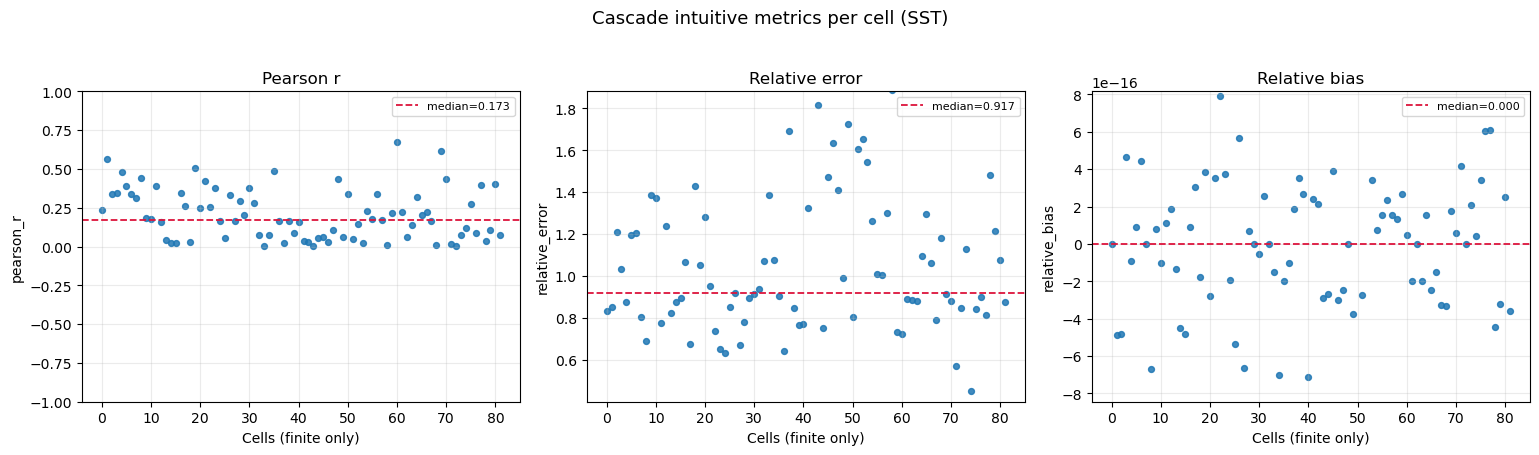

Done. Outputs saved in: Z:\Adam-Lab-Shared\Data\Michal_Rubin\data summery\2026\SST\cascade\intuitive_metrics


In [19]:
# Intuitive Cascade-vs-ground-truth metrics (Pearson, relative error, relative bias)
# Definitions follow the benchmark-style interpretation:
#   FP = sum(max(pred - gt, 0)), FN = sum(max(gt - pred, 0))
#   error = (FP + FN) / sum(abs(gt))
#   bias  = (FP - FN) / sum(abs(gt))
# where gt and pred are firing-rate traces (Hz); integration uses dt = 1/fs_ca.

from pathlib import Path
import io
import base64
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT_DIR = Path(r'Z:\Adam-Lab-Shared\Data\Michal_Rubin\data summery\2026\SST\cascade') / 'intuitive_metrics'
OUT_DIR.mkdir(parents=True, exist_ok=True)

FS_CA_FALLBACK_HZ = 30.0
MIN_VALID_POINTS = 10
USE_LAG_AND_SCALING_IF_AVAILABLE = True  # uses summary_df from previous comprehensive cell if present

import re


def _safe_model_tag(name):
    s = str(name) if name is not None else 'unknown_model'
    s = re.sub(r'[^A-Za-z0-9._-]+', '_', s).strip('_')
    return s if s else 'unknown_model'


MODEL_NAME_USED = globals().get('model_name', 'unknown_model')
MODEL_TAG = _safe_model_tag(MODEL_NAME_USED)
print(f'Using model tag for saved outputs: {MODEL_TAG}')


def _shift_with_nan_local(x, lag_frames):
    x = np.asarray(x, dtype=float)
    y = np.full_like(x, np.nan, dtype=float)
    n = x.size
    lag = int(lag_frames)
    if n == 0:
        return y
    if lag == 0:
        return x.copy()
    if abs(lag) >= n:
        return y
    if lag > 0:
        y[:-lag] = x[lag:]
    else:
        y[-lag:] = x[:lag]
    return y


def _pearson_local(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if x.size < 2 or y.size < 2:
        return np.nan
    sx = np.nanstd(x)
    sy = np.nanstd(y)
    if (not np.isfinite(sx)) or (not np.isfinite(sy)) or sx <= 0 or sy <= 0:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])


def _save_png_svg_html(fig, out_stem: Path, title: str):
    png_path = out_stem.with_suffix('.png')
    svg_path = out_stem.with_suffix('.svg')
    html_path = out_stem.with_suffix('.html')

    fig.savefig(png_path, dpi=200)
    fig.savefig(svg_path)

    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=170, bbox_inches='tight')
    buf.seek(0)
    img_b64 = base64.b64encode(buf.read()).decode('ascii')
    buf.close()

    html = f"""<!doctype html>
<html>
<head><meta charset='utf-8'><title>{title}</title></head>
<body>
  <h3>{title}</h3>
  <img src='data:image/png;base64,{img_b64}' style='max-width:100%; height:auto;' />
</body>
</html>
"""
    html_path.write_text(html, encoding='utf-8')
    print('Saved:', png_path)
    print('Saved:', svg_path)
    print('Saved:', html_path)


if 'all_fr_tr' not in globals() or 'predict_fr_cascade' not in globals():
    raise RuntimeError('Run Cascade prediction first (needs all_fr_tr and predict_fr_cascade).')

pred2d = np.asarray(predict_fr_cascade, dtype=float)
n_cells = min(len(all_fr_tr), int(pred2d.shape[0]), len(all_meta) if 'all_meta' in globals() else len(all_fr_tr))
if n_cells <= 0:
    raise RuntimeError('No cells found for metric computation.')

summary_lookup = None
if USE_LAG_AND_SCALING_IF_AVAILABLE and 'summary_df' in globals() and isinstance(summary_df, pd.DataFrame):
    if 'cell_idx' in summary_df.columns:
        summary_lookup = summary_df.set_index('cell_idx', drop=False)

rows = []
for idx in range(n_cells):
    gt = np.asarray(all_fr_tr[idx], dtype=float).ravel()
    pred = np.asarray(pred2d[idx], dtype=float).ravel()[:gt.size]

    # sampling rate (for integration dt)
    fs_ca = float(FS_CA_FALLBACK_HZ)
    if 'AllCalSR' in globals() and AllCalSR is not None and idx < len(AllCalSR):
        try:
            cand = float(AllCalSR[idx])
            if np.isfinite(cand) and cand > 0:
                fs_ca = cand
        except Exception:
            pass
    dt = 1.0 / fs_ca if fs_ca > 0 else np.nan

    # optional lag+scale correction from previous comprehensive analysis
    lag_frames = 0
    fit_a = 1.0
    fit_b = 0.0
    if summary_lookup is not None and idx in summary_lookup.index:
        rr = summary_lookup.loc[idx]
        try:
            lag_frames = int(rr.get('lag_frames', 0))
        except Exception:
            lag_frames = 0
        try:
            fit_a = float(rr.get('fit_a', 1.0))
        except Exception:
            fit_a = 1.0
        try:
            fit_b = float(rr.get('fit_b', 0.0))
        except Exception:
            fit_b = 0.0

    pred_adj = _shift_with_nan_local(pred, lag_frames)
    pred_adj = fit_a * pred_adj + fit_b

    valid = np.isfinite(gt) & np.isfinite(pred_adj)
    n_valid = int(np.sum(valid))

    if n_valid < MIN_VALID_POINTS:
        pearson = np.nan
        rel_error = np.nan
        rel_bias = np.nan
        fp = np.nan
        fn = np.nan
        gt_abs = np.nan
    else:
        g = gt[valid]
        p = pred_adj[valid]

        pearson = _pearson_local(g, p)

        # false positives/false negatives in rate space (integrated over time -> spikes)
        fp = float(np.nansum(np.clip(p - g, 0.0, None) * dt))
        fn = float(np.nansum(np.clip(g - p, 0.0, None) * dt))
        gt_abs = float(np.nansum(np.abs(g) * dt))

        if np.isfinite(gt_abs) and gt_abs > 0:
            rel_error = float((fp + fn) / gt_abs)
            rel_bias = float((fp - fn) / gt_abs)
        else:
            rel_error = np.nan
            rel_bias = np.nan

    meta = all_meta[idx] if ('all_meta' in globals() and idx < len(all_meta)) else {}
    if not isinstance(meta, dict):
        meta = {'cell_path': str(meta)}

    rows.append({
        'cell_idx': int(idx),
        'cell_path': meta.get('cell_path', ''),
        'state': meta.get('state', ''),
        'segment': meta.get('segment', ''),
        'fs_ca_hz': float(fs_ca),
        'n_frames': int(gt.size),
        'n_valid': int(n_valid),
        'used_lag_frames': int(lag_frames),
        'used_fit_a': float(fit_a),
        'used_fit_b': float(fit_b),
        'pearson_r': pearson,
        'relative_error': rel_error,
        'relative_bias': rel_bias,
        'false_positives_spikes': fp,
        'false_negatives_spikes': fn,
        'gt_abs_spikes': gt_abs,
    })

metrics_df = pd.DataFrame(rows).sort_values('cell_idx').reset_index(drop=True)

csv_path = OUT_DIR / 'cascade_intuitive_metrics_per_cell.csv'
metrics_df.to_csv(csv_path, index=False)
print('Saved per-cell CSV:', csv_path)
print(metrics_df.head(10).to_string(index=False))

# Summary figure: one subplot per metric
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6))
plot_specs = [
    ('pearson_r', 'Pearson r', (-1.0, 1.0)),
    ('relative_error', 'Relative error', None),
    ('relative_bias', 'Relative bias', None),
]

for ax, (col, title, ylim_fixed) in zip(axes, plot_specs):
    vals = metrics_df[col].to_numpy(dtype=float)
    finite = np.isfinite(vals)
    x = np.arange(np.sum(finite))
    y = vals[finite]

    if y.size:
        ax.scatter(x, y, s=18, alpha=0.85, color='tab:blue')
        med = float(np.nanmedian(y))
        ax.axhline(med, color='crimson', linestyle='--', linewidth=1.3, label=f'median={med:.3f}')
        ax.legend(fontsize=8)

    ax.set_title(title)
    ax.set_xlabel('Cells (finite only)')
    ax.set_ylabel(col)
    ax.grid(alpha=0.25)

    if ylim_fixed is not None:
        ax.set_ylim(*ylim_fixed)
    elif y.size:
        lo = float(np.nanpercentile(y, 2))
        hi = float(np.nanpercentile(y, 98))
        if np.isfinite(lo) and np.isfinite(hi) and hi > lo:
            pad = 0.1 * (hi - lo)
            ax.set_ylim(lo - pad, hi + pad)

fig.suptitle('Cascade intuitive metrics per cell (SST)', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95])

_save_png_svg_html(
    fig,
    OUT_DIR / f'cascade_intuitive_metrics_summary__{MODEL_TAG}',
    title='Cascade intuitive metrics summary (SST)',
)
plt.show()

# Extra figure: histogram of Pearson correlation across cells
pear = metrics_df['pearson_r'].to_numpy(dtype=float)
pear = pear[np.isfinite(pear)]

fig_h, ax_h = plt.subplots(figsize=(6.5, 4.6))
if pear.size:
    n_bins = max(10, min(40, int(np.sqrt(pear.size) * 2)))
    ax_h.hist(pear, bins=n_bins, color='tab:blue', alpha=0.85, edgecolor='white')
    med = float(np.nanmedian(pear))
    ax_h.axvline(med, color='crimson', linestyle='--', linewidth=1.4, label=f'median={med:.3f}')
    ax_h.legend(fontsize=8)
ax_h.set_title('Pearson correlation histogram (Cascade vs ground truth)')
ax_h.set_xlabel('Pearson r')
ax_h.set_ylabel('Number of cells')
ax_h.set_xlim(-1.0, 1.0)
ax_h.grid(alpha=0.25)
fig_h.tight_layout()

_save_png_svg_html(
    fig_h,
    OUT_DIR / f'cascade_intuitive_metrics_pearson_histogram__{MODEL_TAG}',
    title='Cascade intuitive metrics Pearson histogram (SST)',
)
plt.show()

print('Done. Outputs saved in:', OUT_DIR)




In [ ]:
# Lag-corrected Cascade vs real FR event analysis + figures (SVG+HTML)
from pathlib import Path
from cascade_lag_diff_events_tools_v2 import run_lag_diff_event_analysis

OUT_DIR = Path(r'Z:\\Adam-Lab-Shared\\Data\\Michal_Rubin\\data summery\\2026\\Pyr\\cascade_base')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Set this to correct calcium-vs-FR lag (seconds). Positive => Cascade delayed => shift earlier.
LAG_S = 0.1

results = run_lag_diff_event_analysis(
    cal_traces=all_cal_tr,
    vol_traces=all_vol_tr,
    spike_idx_vol_list=all_spTr,
    fr_real_list=all_fr_tr,
    fr_pred_2d=predict_fr_cascade,
    cell_names=all_name,
    out_dir=OUT_DIR,
    lag_s=LAG_S,
    fs_ca_hz=30.0,
    fs_vol_hz=500.0,
    diff_method='resid_robust_z',
    resid_robust_z_k=3.0,
    pre_s=0.100,
    post_s=0.200,
    save_indices_csv=True,
    save_segments_npz=True,
    fig3_max_rows_per_fig=None,  # set e.g. 25 to paginate Fig3
)

overshoot_idx_lists = [r.overshoot_idx.tolist() for r in results]
undershoot_idx_lists = [r.undershoot_idx.tolist() for r in results]
print('Saved figures + CSV/NPZ to:', str(OUT_DIR))
print('Example cell0 overshoot frames:', overshoot_idx_lists[0][:10] if overshoot_idx_lists else [])
print('Example cell0 undershoot frames:', undershoot_idx_lists[0][:10] if undershoot_idx_lists else [])
